# Training YOLO for Custom Classes

**Goal**: Use transfer learning to fine-tune a pre-trained YOLO model on specific object classes. 

**Objectives**

 - Convert bounding boxes to a new representation.
 
 - Assemble files into the desired directory structure.
 
 - Cleanly handle malformed data.
 
 - Fine-tune a model to detect new classes. 
 
 - Detect these new classes in images.

**Getting Started**

In [3]:
import pathlib
import random
import shutil
import sys
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import torch
import ultralytics
import yaml
from IPython import display
from PIL import Image
from tqdm.notebook import tqdm
from ultralytics import YOLO

In [4]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("matplotlib version:", plt.matplotlib.__version__)
print("pandas version:", pd.__version__)
print("PIL version:", Image.__version__)
print("PyYAML version:", yaml.__version__)
print("torch version:", torch.__version__)
print("ultralytics version:", ultralytics.__version__)

Platform: linux
Python version: 3.12.1 (main, Mar 17 2025, 17:13:06) [GCC 9.4.0]
---
matplotlib version: 3.10.1
pandas version: 2.2.3
PIL version: 11.1.0
PyYAML version: 6.0.2
torch version: 2.6.0+cpu
ultralytics version: 8.3.99


In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

Using cpu device.


**Data Transformation**

Data_images directory structure:

In [6]:
!tree data_images --filelimit=10

data_images
├── test [500 entries exceeds filelimit, not opening dir]
└── train
    ├── annotations [813 entries exceeds filelimit, not opening dir]
    └── images [813 entries exceeds filelimit, not opening dir]

4 directories, 0 files


In [7]:
training_dir = pathlib.Path("data_images", "train")
images_dir = training_dir / "images"
annotations_dir = training_dir /"annotations"

print("Images     :", images_dir)
print("Annotations:", annotations_dir)

Images     : data_images/train/images
Annotations: data_images/train/annotations


In [8]:
!head -n 25 $annotations_dir/01.xml

<annotation>
	<folder>Images</folder>
	<filename>02_Motijheel_280714_0005.jpg</filename>
	<path>E:\Datasets\Dataset\Images\02_Motijheel_280714_0005.jpg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>1200</width>
		<height>800</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>bus</name>
		<pose>Unspecified</pose>
		<truncated>1</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>833</xmin>
			<ymin>390</ymin>
			<xmax>1087</xmax>
			<ymax>800</ymax>
		</bndbox>
	</object>


Assigning classes:

In [9]:
classes = [
    "ambulance",
    "army vehicle",
    "auto rickshaw",
    "bicycle",
    "bus",
    "car",
    "garbagevan",
    "human hauler",
    "minibus",
    "minivan",
    "motorbike",
    "pickup",
    "policecar",
    "rickshaw",
    "scooter",
    "suv",
    "taxi",
    "three wheelers (CNG)",
    "truck",
    "van",
    "wheelbarrow",
]

A dictionary that maps the classes names to their indices.

In [10]:
class_mapping = {cls: idx for idx, cls in enumerate(classes)}

print(class_mapping)

{'ambulance': 0, 'army vehicle': 1, 'auto rickshaw': 2, 'bicycle': 3, 'bus': 4, 'car': 5, 'garbagevan': 6, 'human hauler': 7, 'minibus': 8, 'minivan': 9, 'motorbike': 10, 'pickup': 11, 'policecar': 12, 'rickshaw': 13, 'scooter': 14, 'suv': 15, 'taxi': 16, 'three wheelers (CNG)': 17, 'truck': 18, 'van': 19, 'wheelbarrow': 20}


Working on bounding boxes by hand:

In [11]:
width = 1200
height = 800
xmin = 833
ymin = 390
xmax = 1087
ymax = 800

Compute the center of the bounding box:

In [12]:
x_center = (xmax + xmin) /2
y_center = (ymax - ymin) / 2

print(f"Bounding box center: ({x_center}, {y_center})")

Bounding box center: (960.0, 205.0)


Compute the width and height of the bounding box

In [13]:
bb_width = (xmax - xmin) / width
bb_height = (ymax - ymin)/ height

print(f"Bounding box size: {bb_width:0.3f} ⨯ {bb_height:0.3f}")

Bounding box size: 0.212 ⨯ 0.512


Bounding Box Function:

In [14]:
def xml_to_yolo_bbox(bbox, width, height):
    """Convert the XML bounding box coordinates into YOLO format.

    Input:  bbox    The bounding box, defined as [xmin, ymin, xmax, ymax],
                    measured in pixels.
            width   The image width in pixels.
            height  The image height in pixels.

    Output: [x_center, y_center, bb_width, bb_height], where the bounding
            box is centered at (x_center, y_center) and is of size
            bb_width x bb_height.  All values are measured as a fraction
            of the image size."""

    xmin, ymin, xmax, ymax = bbox
    x_center = (xmax + xmin) /2
    y_center = (ymax - ymin) / 2
    bb_width = (xmax - xmin) / width
    bb_height = (ymax - ymin)/ height

    return [x_center, y_center, bb_width, bb_height]


xml_to_yolo_bbox([xmin, ymin, xmax, ymax], width, height)

[960.0, 205.0, 0.21166666666666667, 0.5125]

**XML Object Parsing**

A function to parse all of the objects in an XML file:

In [15]:
def parse_annotations(f):
    """Parse all of the objects in a given XML file to YOLO format.

    Input:  f      The path of the file to parse.

    Output: A list of objects in YOLO format.
            Each object is a list [index, x_center, y_center, width, height]."""

    objects = []

    tree = ET.parse(f)
    root = tree.getroot()
    width = int(root.find("size").find("width").text)
    height = int(root.find("size").find("height").text)

    for obj in root.findall("object"):
        label = obj.find("name").text
        class_id = class_mapping[label]
        bndbox = obj.find("bndbox")
        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)
        yolo_bbox = xml_to_yolo_bbox([xmin, ymin, xmax, ymax], width, height)

        objects.append([class_id] + yolo_bbox)

    return objects


objects = parse_annotations(annotations_dir / "01.xml")
print("First object:", objects[0])

First object: [4, 960.0, 205.0, 0.21166666666666667, 0.5125]


A function that outputs the YOLO objects in the text format

In [16]:
def write_label(objects, filename):
    """Write the annotations to a file in the YOLO text format.

    Input:  objects   A list of YOLO objects, each a list of numbers.
            filename  The path to write the text file."""

    with open(filename, "w") as f:
        for obj in objects:
            # Write the object out as space-separated values
            f.write(" ".join(str(x) for x in obj))
            # Write a newline
            f.write("\n")

In [17]:
write_label(objects, "yolo_test.txt")
!head -n 1 yolo_test.txt

4 960.0 205.0 0.21166666666666667 0.5125


**Preparing the Directory Structure**

*Image Type Detection*

 Determine the types of images in the training set, from their file extensions.

In [18]:
extensions = set([f.suffix for f in list(images_dir.glob("*"))])
print(extensions)

{'.jpg', '.jpeg', '.png', '.JPG'}


Convert all of the images to RGB JPEG files before feeding them into YOLO

In [19]:
def convert_image(fin, fout):
    """Open the image at `fin`, convert to a RGB JPEG, and save at `fout`."""
    Image.open(fin).convert("RGB").save(fout, "JPEG")

Convert the PNG image 193.png to a JPEG. 

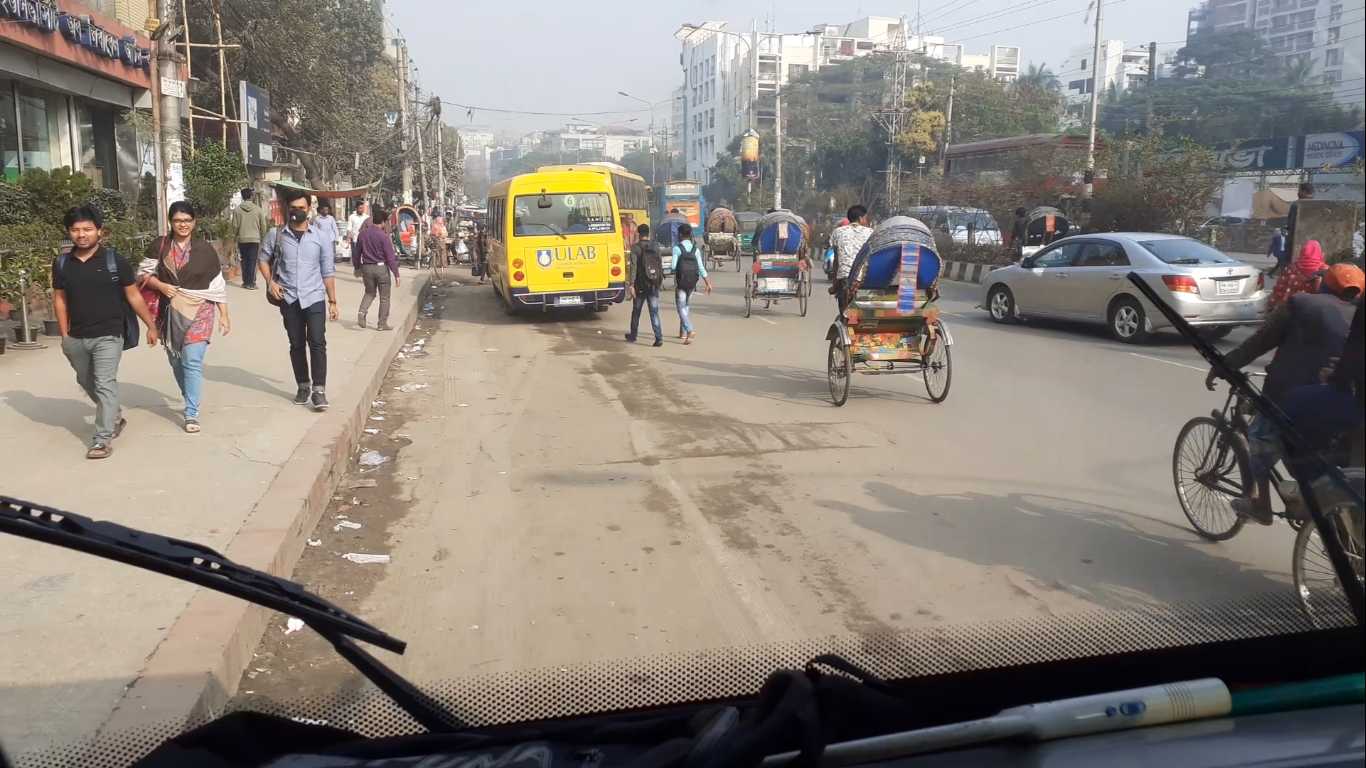

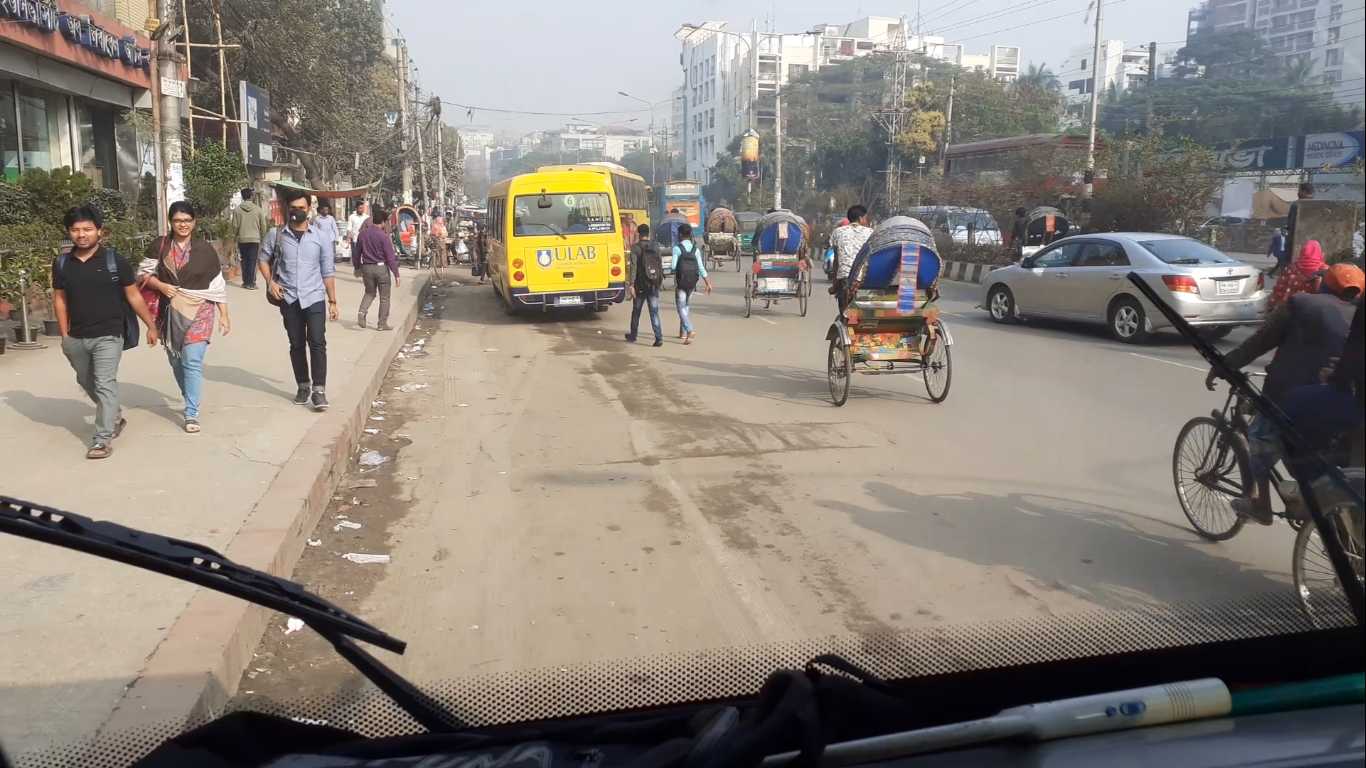

In [20]:
test_image = images_dir / "193.png"
convert_image(test_image, "test_image.jpg")

display.display(
    Image.open(images_dir / "193.png"),
    Image.open(test_image)  

)

The directory structure for YOLO training.

In [21]:
yolo_base = pathlib.Path("data_yolo")

# It's important to clear out the directory, if it already
# exists.  We'll get a different train / validation split
# each time, so we need to make sure the old images are
# cleared out.
shutil.rmtree(yolo_base, ignore_errors=True)

(yolo_base / "images" / "train").mkdir(parents=True)
# Create the remaining directories.
(yolo_base / "images" / "val").mkdir(parents=True)
(yolo_base / "labels" / "train").mkdir(parents=True)
(yolo_base / "labels" / "val").mkdir(parents=True)

!tree $yolo_base

data_yolo
├── images
│   ├── train
│   └── val
└── labels
    ├── train
    └── val

6 directories, 0 files


In [22]:
train_frac = 0.8
images = list(images_dir.glob("*"))

for img in tqdm(images):
    split = "train" if random.random() < train_frac else "val"

    annotation = annotations_dir / f"{img.stem}.xml"
    # This might raise an error:
    try:
        parsed = parse_annotations(annotation)
    except Exception as e:
        print(f'Failed to pass "{img.stem}".Skipping')
    
    dest = yolo_base / "labels" / split / f"{img.stem}.txt"
    write_label(parsed, dest)

    dest = yolo_base / "images" / split / f"{img.stem}.jpg"
    convert_image(img, dest)

  0%|          | 0/813 [00:00<?, ?it/s]

Failed to pass "231".Skipping


Checking for 80/20 split between training and validation.

In [23]:
train_count = len(list((yolo_base / "images" / "train").glob("*")))
val_count = len(list((yolo_base / "images" / "val").glob("*")))
total_count = train_count + val_count

print(f"Training fraction:   {train_count/total_count:0.3f}")
print(f"Validation fraction: {val_count/total_count:0.3f}")

Training fraction:   0.804
Validation fraction: 0.196


**Training the Model**

The data for training a YOLO model needs to be described in a YAML file. YAML is a structured document format, somewhat like JSON. (In fact, YAML is a superset of JSON, so any JSON document is also a valid YAML file.) Python dictionaries, lists, strings, and numbers map naturally to YAML constructions, so we'll start by defining a dictionary with the necessary keys.

In [24]:
metadata = {
    "path": str(
        yolo_base.absolute()
    ),  # It's easier to specify absolute paths with YOLO.
    
    "train": "images/train", # Training images, relative to above.
    
    "val": "images/val", # Validation images
    
    "names": classes, # Class names, as a list
    
    "nc": len(classes), # Number of classes
}

print(metadata)

{'path': '/workspaces/applied-ai/0x02-traffic_monitoring_in_bangladesh/data_yolo', 'train': 'images/train', 'val': 'images/val', 'names': ['ambulance', 'army vehicle', 'auto rickshaw', 'bicycle', 'bus', 'car', 'garbagevan', 'human hauler', 'minibus', 'minivan', 'motorbike', 'pickup', 'policecar', 'rickshaw', 'scooter', 'suv', 'taxi', 'three wheelers (CNG)', 'truck', 'van', 'wheelbarrow'], 'nc': 21}


Save YAML file:

In [25]:
yolo_config = "data.yaml"
# Using yaml.safe_dump() protects you from some oddities in the YAML format.
# It takes the same arguments as json.dump().
yaml.safe_dump(metadata, open(yolo_config, 'w'))


!cat data.yaml

names:
- ambulance
- army vehicle
- auto rickshaw
- bicycle
- bus
- car
- garbagevan
- human hauler
- minibus
- minivan
- motorbike
- pickup
- policecar
- rickshaw
- scooter
- suv
- taxi
- three wheelers (CNG)
- truck
- van
- wheelbarrow
nc: 21
path: /workspaces/applied-ai/0x02-traffic_monitoring_in_bangladesh/data_yolo
train: images/train
val: images/val


-  We'll use the YOLOv8n (n for nano) model. The nano model is less than 30% of the size of the small model, but it still manages 80% of the small model's performance. This'll cut down the training time without hurting performance too much.

Load pre-trained model

In [34]:
model = YOLO("runs/detect/train/weights/last.pt")

In [39]:
save_dir = Path("runs/detect/train/weights/")

**Evaluating the Model**

In [40]:
print(save_dir)

runs/detect/train/weights


In [41]:
!tree $save_dir

runs/detect/train/weights
├── best.pt
└── last.pt

0 directories, 2 files


In [ ]:
Image.open(save_dir / "PR_curve.png")